# Exercises 3 – Car ownership

In [35]:
# Imports and dataset load (placed at top so cells can run standalone)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
from pathlib import Path

# Display options
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)

# Load dataset files used in this notebook
DATA_PATH = Path('bilejerskab2026.xlsx')
if DATA_PATH.exists():
    df_bilejerskab = pd.read_excel(DATA_PATH)
else:
    raise FileNotFoundError(f'Expected dataset not found: {DATA_PATH}')

# Make a working copy for modeling (some cells expect df_model)
df_model = df_bilejerskab.copy()
# Remove any AgeG_New_* columns that should not be used anywhere
ageg_new_cols = [c for c in df_bilejerskab.columns if str(c).startswith('AgeG_New')]
if ageg_new_cols:
    df_bilejerskab = df_bilejerskab.drop(columns=ageg_new_cols)
    print('Dropped AgeG_New cols from df_bilejerskab:', ageg_new_cols)
ageg_new_model_cols = [c for c in df_model.columns if str(c).startswith('AgeG_New')]
if ageg_new_model_cols:
    df_model = df_model.drop(columns=ageg_new_model_cols)
    print('Dropped AgeG_New cols from df_model:', ageg_new_model_cols)

print('Loaded', len(df_bilejerskab), 'rows from', DATA_PATH)
print('Columns:', list(df_bilejerskab.columns)[:30])


Loaded 7853 rows from bilejerskab2026.xlsx
Columns: ['ID', 'HHLicenses', 'Gender', 'Children', 'Year', 'AgeGroup', 'LMA', 'Car', 'HHIncome', 'PerIncome']


/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


## Load dataset

## a) Find the market shares for 0, 1 and 2 cars in the data. Discuss whether the market shares change between 2008 and 2009?

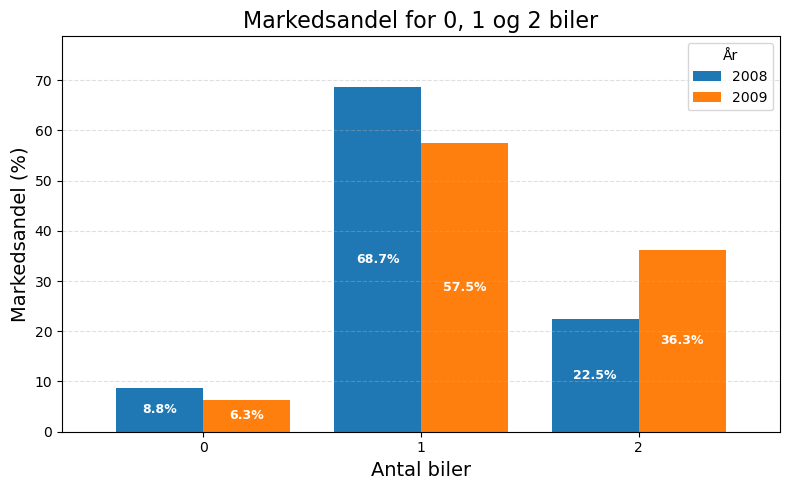

In [9]:
# Prepare plot_df and plot market shares for 0,1,2 cars (handles 2008 vs 2009 if a year column exists)
# Ensure dataset is loaded (top cell should have created df_bilejerskab)
if 'df_bilejerskab' not in globals():
    raise RuntimeError('df_bilejerskab not found - run the top data-loading cell first')

# Detect a year column (case-insensitive, matches 'year', 'år', 'aar')
year_col = None
for c in df_bilejerskab.columns:
    cn = str(c).lower()
    if 'year' in cn or 'år' in cn or 'aar' in cn:
        year_col = c
        break

# Build plot_df: rows = car counts (0,1,2), columns = years (or 'All') with percentages
if year_col is not None:
    tmp = df_bilejerskab.groupby([year_col, 'Car']).size().unstack(fill_value=0)
    # Keep only car categories 0,1,2 (if present)
    for cat in [0,1,2]:
        if cat not in tmp.columns:
            tmp[cat] = 0
    tmp = tmp[[0,1,2]]
    # Convert to percentages by year and transpose so index=0,1,2 and columns=years
    plot_df = (tmp.div(tmp.sum(axis=1), axis=0) * 100).T
else:
    counts = df_bilejerskab['Car'].value_counts().reindex([0,1,2], fill_value=0)
    plot_df = (counts / counts.sum() * 100).to_frame(name='All')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
plot_df.plot(kind='bar', ax=ax, width=0.8, color=None)

# Add text labels inside the bars (percentage values)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9, weight='bold', color='white')

ax.set_title('Markedsandel for 0, 1 og 2 biler', fontsize=16)
ax.set_xlabel('Antal biler', fontsize=14)
ax.set_ylabel('Markedsandel (%)', fontsize=14)
ax.set_xticklabels([str(int(x)) for x in plot_df.index], rotation=0)
if plot_df.shape[1] > 1:
    ax.legend(title='År')
else:
    ax.get_legend().remove()
ax.set_ylim(0, max(plot_df.max().max(), 1) + 10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

<br>

## b) Describe how the number of cars relates to number of driver’s licenses, income and number of kids, e.g. using cross tabulation, group averages or correlations. Comment on the results.

In [10]:
# b) Relation between number of cars and licenses, income, and children

# 1) cars_driver_license: average number of cars for HHLicenses = 1,2,3,4,5
cars_driver_license = (
    df_bilejerskab[df_bilejerskab['HHLicenses'].isin([1, 2, 3, 4, 5])]
    .groupby('HHLicenses', as_index=False)
    .agg(
        AvgCars=('Car', 'mean'),
        N=('Car', 'size')
    )
    .sort_values('HHLicenses')
)
cars_driver_license['AvgCars'] = cars_driver_license['AvgCars'].round(3)

# 2) cars_income: average number of cars by HHIncome intervals (quantile-based bins)
income_bins = pd.qcut(df_bilejerskab['HHIncome'], q=5, duplicates='drop')
cars_income = (
    df_bilejerskab.assign(HHIncomeInterval=income_bins)
    .groupby('HHIncomeInterval', as_index=False, observed=False)
    .agg(
        AvgCars=('Car', 'mean'),
        N=('Car', 'size')
    )
    .sort_values('HHIncomeInterval')
)
cars_income['AvgCars'] = cars_income['AvgCars'].round(3)

# 3) cars_kids: average number of cars for Children = 0,1,2,3,4,5,6
cars_kids = (
    df_bilejerskab[df_bilejerskab['Children'].isin([0, 1, 2, 3, 4, 5, 6])]
    .groupby('Children', as_index=False)
    .agg(
        AvgCars=('Car', 'mean'),
        N=('Car', 'size')
    )
    .sort_values('Children')
)
cars_kids['AvgCars'] = cars_kids['AvgCars'].round(3)

print('cars_driver_license')
display(cars_driver_license)

print('cars_income')
display(cars_income)

print('cars_kids')
display(cars_kids)

cars_driver_license


,HHLicenses,AvgCars,N
0,1,0.819,1167
1,2,1.269,5973
2,3,1.484,490
3,4,1.521,73
4,5,1.250,4


cars_income


,HHIncomeInterval,AvgCars,N
0,"(-0.001, 349.0]",0.848,1577
1,"(349.0, 525.8]",1.116,1564
2,"(525.8, 657.0]",1.262,1592
3,"(657.0, 811.0]",1.318,1567
4,"(811.0, 10558.0]",1.435,1553


cars_kids


,Children,AvgCars,N
0,0,1.121,4629
1,1,1.250,1186
2,2,1.309,1506
3,3,1.396,470
4,4,1.440,50
5,5,1.500,10
6,6,0.500,2


**Kommentar til resultater (b)**
- **Driver's licenses:** Gennemsnitligt antal biler stiger fra ca. 0.82 (1 licens) til ca. 1.52 (4 licenser). Kategorien med 5 licenser har meget få observationer (N=4), så den er usikker.
- **Indkomst:** Der er en tydelig positiv sammenhaeng mellem indkomst og antal biler. AvgCars stiger gradvist fra ca. 0.85 i laveste interval til ca. 1.44 i hoejeste interval.
- **Boern:** AvgCars stiger overordnet med antal boern (fra ca. 1.12 ved 0 boern til ca. 1.50 ved 5 boern). Kategorien med 6 boern har kun N=2 og boer tolkes med stor forsigtighed.

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# 1) Cross tabulations (row percentages) with N
crosstab_license = pd.crosstab(
    df_bilejerskab["HHLicenses"],
    df_bilejerskab["Car"],
    normalize="index"
).round(3)
crosstab_license["N"] = df_bilejerskab.groupby("HHLicenses").size()

crosstab_kids = pd.crosstab(
    df_bilejerskab["Children"],
    df_bilejerskab["Car"],
    normalize="index"
).round(3)
crosstab_kids["N"] = df_bilejerskab.groupby("Children").size()

# Crosstab for income with fixed intervals + N
income_bins = [0, 300, 500, 700, 900, 1200, np.inf]
income_labels = [
    "0-300",
    "301-500",
    "501-700",
    "701-900",
    "901-1200",
    "1200+"
]
income_intervals_for_crosstab = pd.cut(
    df_bilejerskab["HHIncome"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
    )
crosstab_income = pd.crosstab(
    income_intervals_for_crosstab,
    df_bilejerskab["Car"],
    normalize="index"
).round(3)
crosstab_income["N"] = income_intervals_for_crosstab.value_counts().reindex(crosstab_income.index).astype(int)

# 3) Spearman correlations
corr_rows = []
for x in ["HHLicenses", "HHIncome", "Children"]:
    rho, pval = spearmanr(df_bilejerskab["Car"], df_bilejerskab[x], nan_policy="omit")
    corr_rows.append({"Variable": x, "SpearmanRho": round(rho, 3), "PValue": pval})

correlation_table = pd.DataFrame(corr_rows)

print("Cross tab: Car vs HHLicenses (row shares + N)")
display(crosstab_license)

print("Cross tab: Car vs Children (row shares + N)")
display(crosstab_kids)

print("Cross tab: Car vs HHIncome interval (fixed intervals, row shares + N)")
display(crosstab_income)

print("Spearman correlations with Car")
display(correlation_table)

Cross tab: Car vs HHLicenses (row shares + N)


Car,0,1,2,N
HHLicenses,,,,
0,0.952,0.048,0.000,146
1,0.215,0.751,0.034,1167
2,0.038,0.655,0.307,5973
3,0.004,0.508,0.488,490
4,0.014,0.452,0.534,73
5,0.000,0.750,0.250,4


Cross tab: Car vs Children (row shares + N)


Car,0,1,2,N
Children,,,,
0,0.103,0.672,0.225,4629
1,0.060,0.631,0.309,1186
2,0.037,0.617,0.346,1506
3,0.023,0.557,0.419,470
4,0.020,0.520,0.460,50
5,0.000,0.500,0.500,10
6,0.500,0.500,0.000,2


Cross tab: Car vs HHIncome interval (fixed intervals, row shares + N)


...

Car,0,1,2,N
Children,,,,
0,0.103,0.672,0.225,4629
1,0.060,0.631,0.309,1186
2,0.037,0.617,0.346,1506
3,0.023,0.557,0.419,470
4,0.020,0.520,0.460,50
5,0.000,0.500,0.500,10
6,0.500,0.500,0.000,2


Cross tab: Car vs HHIncome interval (fixed intervals, row shares + N)


Car,0,1,2,N
HHIncome,,,,
0-300,0.248,0.691,0.061,1198
301-500,0.103,0.733,0.165,1579
501-700,0.040,0.664,0.296,2437
701-900,0.024,0.602,0.374,1576
901-1200,0.025,0.525,0.451,728
1200+,0.015,0.445,0.540,335


Spearman correlations with Car


,Variable,SpearmanRho,PValue
0,HHLicenses,0.365,1.978236e-245
1,HHIncome,0.352,1.479155e-227
2,Children,0.166,1.318896e-49


<br>

## c) Estimate a logistic regression, where you model whether a family has a car or not. 
Includeas many variables as possible to explain behaviour and consider non-linear effects. Comment
on the estimated parameters and argue for your choice of final model.

Dummier for aldersgrupper

In [12]:
# Create dummy columns for AgeGroup
if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

agegroup_map = {
    2: '8-14',
    3: '15-18',
    4: '19-24',
    5: '25-29',
    6: '30-54',
    7: '55-64',
    8: '65-74',
    9: '75-84'
}

df_bilejerskab['AgeGroupLabel'] = df_bilejerskab['AgeGroup'].map(agegroup_map)

agegroup_dummies = pd.get_dummies(df_bilejerskab['AgeGroupLabel'], prefix='AgeGroup')
df_bilejerskab = pd.concat([df_bilejerskab, agegroup_dummies], axis=1)

df_bilejerskab[['AgeGroup', 'AgeGroupLabel'] + list(agegroup_dummies.columns)].head()

,AgeGroup,AgeGroupLabel,AgeGroup_15-18,AgeGroup_19-24,AgeGroup_25-29,AgeGroup_30-54,AgeGroup_55-64,AgeGroup_65-74,AgeGroup_75-84,AgeGroup_8-14
0,7,55-64,False,False,False,False,True,False,False,False
1,6,30-54,False,False,False,True,False,False,False,False
2,7,55-64,False,False,False,False,True,False,False,False
3,6,30-54,False,False,False,True,False,False,False,False
4,7,55-64,False,False,False,False,True,False,False,False


In [13]:
# Age group distribution
if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

# Ensure the AgeGroupLabel column exists
if 'AgeGroupLabel' not in df_bilejerskab.columns:
    agegroup_map = {
        2: '8-14',
        3: '15-18',
        4: '19-24',
        5: '25-29',
        6: '30-54',
        7: '55-64',
        8: '65-74',
        9: '75-84'
    }
    df_bilejerskab['AgeGroupLabel'] = df_bilejerskab['AgeGroup'].map(agegroup_map)

# Create age group distribution
age_dist = (
    df_bilejerskab['AgeGroupLabel']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'AgeGroupLabel': 'Count'})
)
age_dist.columns = ['AgeGroup', 'Count']
age_dist['Percentage'] = (age_dist['Count'] / age_dist['Count'].sum() * 100).round(2)

print("=" * 60)
print("AGE GROUP DISTRIBUTION")
print("=" * 60)
display(age_dist)
print(f"\nTotal observations: {age_dist['Count'].sum()}")

AGE GROUP DISTRIBUTION


AGE GROUP DISTRIBUTION


,AgeGroup,Count,Percentage
0,15-18,45,0.57
1,19-24,281,3.58
2,25-29,457,5.82
3,30-54,4372,55.67
4,55-64,1588,20.22
5,65-74,861,10.96
6,75-84,242,3.08
7,8-14,7,0.09



Total observations: 7853


In [14]:
# Cross table for aldersgrupper og antal biler
import pandas as pd

if 'df_bilejerskab' not in globals():
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

# Ensure the age group label exists
if 'AgeGroupLabel' not in df_bilejerskab.columns:
    agegroup_map = {
        2: '8-14',
        3: '15-18',
        4: '19-24',
        5: '25-29',
        6: '30-54',
        7: '55-64',
        8: '65-74',
        9: '75-84'
    }
    df_bilejerskab['AgeGroupLabel'] = df_bilejerskab['AgeGroup'].map(agegroup_map)

age_order = ['8-14', '15-18', '19-24', '25-29', '30-54', '55-64', '65-74', '75-84']

# Absolute counts
crosstab_age_car = pd.crosstab(
    df_bilejerskab['AgeGroupLabel'],
    df_bilejerskab['Car'],
    margins=True
).reindex(age_order + ['All'])

# Row percentages for easier interpretation, with N as the last column
crosstab_age_car_pct = pd.crosstab(
    df_bilejerskab['AgeGroupLabel'],
    df_bilejerskab['Car'],
    normalize='index'
).reindex(age_order).round(3) * 100
crosstab_age_car_pct['N'] = crosstab_age_car.loc[age_order, [0, 1, 2]].fillna(0).sum(axis=1).astype(int)
crosstab_age_car_pct = crosstab_age_car_pct[[col for col in crosstab_age_car_pct.columns if col != 'N'] + ['N']]

print('Krydstabel: aldersgrupper vs. antal biler')
display(crosstab_age_car.fillna(0).astype(int))

print('Rækkeprocenter (%)')
display(crosstab_age_car_pct)


Krydstabel: aldersgrupper vs. antal biler


Krydstabel: aldersgrupper vs. antal biler


Car,0,1,2,All
AgeGroupLabel,,,,
8-14,1,6,0,7
15-18,5,23,17,45
19-24,133,116,32,281
25-29,106,257,94,457
30-54,221,2665,1486,4372
55-64,59,1123,406,1588
65-74,57,695,109,861
75-84,36,197,9,242
All,618,5082,2153,7853


Rækkeprocenter (%)


Car,0,1,2,N
AgeGroupLabel,,,,
8-14,14.3,85.7,0.0,7
15-18,11.1,51.1,37.8,45
19-24,47.3,41.3,11.4,281
25-29,23.2,56.2,20.6,457
30-54,5.1,61.0,34.0,4372
55-64,3.7,70.7,25.6,1588
65-74,6.6,80.7,12.7,861
75-84,14.9,81.4,3.7,242


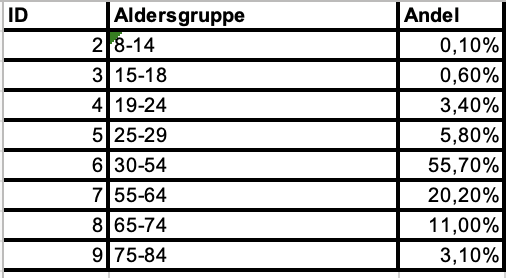

Dummies for om de har en bil

In [15]:
# Binary target for logistic regression: 1 if the family has at least one car, otherwise 0
if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

df_bilejerskab['HaveCar'] = df_bilejerskab['Car'].isin([1, 2]).astype(int)

df_bilejerskab[['Car', 'HaveCar']].head()

,Car,HaveCar
0,1,1
1,1,1
2,1,1
3,2,1
4,2,1


Dummies for beskæftigelse

In [16]:
# Create dummy columns for LMA using the supplied ID mapping
if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

lma_map = {
    1: 'Fuldtidsjob',
    2: 'Deltidsjob',
    3: 'Elev_eller_studerende',
    4: 'Pensioneret',
    5: 'Arbejdssoegende',
    6: 'Uden_for_arbejdsmarkedet'
}

df_bilejerskab['LMA_Label'] = df_bilejerskab['LMA'].map(lma_map)

lma_dummies = pd.get_dummies(df_bilejerskab['LMA_Label'], prefix='LMA')
# Rename columns to remove spaces
lma_dummies.columns = lma_dummies.columns.str.replace(' ', '_').str.replace('ø', 'o').str.replace('æ', 'ae')
df_bilejerskab = pd.concat([df_bilejerskab, lma_dummies], axis=1)

df_bilejerskab[['LMA', 'LMA_Label'] + list(lma_dummies.columns)].head()

,LMA,LMA_Label,LMA_Arbejdssoegende,LMA_Deltidsjob,LMA_Elev_eller_studerende,LMA_Fuldtidsjob,LMA_Pensioneret,LMA_Uden_for_arbejdsmarkedet
0,1,Fuldtidsjob,False,False,False,True,False,False
1,1,Fuldtidsjob,False,False,False,True,False,False
2,1,Fuldtidsjob,False,False,False,True,False,False
3,1,Fuldtidsjob,False,False,False,True,False,False
4,1,Fuldtidsjob,False,False,False,True,False,False


In [17]:
# LMA distribution: count and percentage per employment category

import pandas as pd

if 'df_bilejerskab' not in globals():
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

# Ensure the label column exists
if 'LMA_Label' not in df_bilejerskab.columns:
    lma_map = {
        1: 'Fuldtidsjob',
        2: 'Deltidsjob',
        3: 'Elev_eller_studerende',
        4: 'Pensioneret',
        5: 'Arbejdssoegende',
        6: 'Uden_for_arbejdsmarkedet'
    }
    df_bilejerskab['LMA_Label'] = df_bilejerskab['LMA'].map(lma_map)

lma_order = [
    'Fuldtidsjob',
    'Deltidsjob',
    'Elev_eller_studerende',
    'Pensioneret',
    'Arbejdssoegende',
    'Uden_for_arbejdsmarkedet'
]

lma_dist = (
    df_bilejerskab['LMA_Label']
    .value_counts()
    .reindex(lma_order)
    .rename_axis('LMA_Label')
    .reset_index(name='Count')
)

lma_dist['Percentage'] = (lma_dist['Count'] / lma_dist['Count'].sum() * 100).round(2)

print("=" * 80)
print("DISTRIBUTION OF LMA (EMPLOYMENT STATUS)")
print("=" * 80)
display(lma_dist)

print(f"\nTotal observations: {lma_dist['Count'].sum()}")
print(f"Categories with < 10 observations: {(lma_dist['Count'] < 10).sum()}")
print(f"Categories with < 50 observations: {(lma_dist['Count'] < 50).sum()}")


DISTRIBUTION OF LMA (EMPLOYMENT STATUS)


DISTRIBUTION OF LMA (EMPLOYMENT STATUS)


,LMA_Label,Count,Percentage
0,Fuldtidsjob,4455,56.73
1,Deltidsjob,1227,15.62
2,Elev_eller_studerende,397,5.06
3,Pensioneret,1256,15.99
4,Arbejdssoegende,94,1.20
5,Uden_for_arbejdsmarkedet,424,5.40



Total observations: 7853
Categories with < 10 observations: 0
Categories with < 50 observations: 0


Dummy for køn. Female = 1

In [18]:
# Create binary dummy for Gender: Male (1) = 0, Female (2) = 1
df_bilejerskab['Female'] = (df_bilejerskab['Gender'] == 2).astype(int)

df_bilejerskab[['Gender', 'Female']].head()

,Gender,Female
0,2,1
1,1,0
2,1,0
3,1,0
4,1,0


Dummies for Licenses

Her laves for 0, 1 og 2+. Dette er en vurdering ud fra at kigge på Cross Tables

In [19]:
# Create dummies for HHLicenses with 0 licenses as reference
# 1 license gets its own dummy, and 2+ licenses are grouped together.
def add_hhlicenses_dummies(df, source_col='HHLicenses'):
    df = df.copy()
    df['HHLicenses_1'] = (df[source_col] == 1).astype(int)
    df['HHLicenses_2plus'] = df[source_col].isin([2, 3, 4, 5]).astype(int)
    return df

# Quick check on the transformed columns
df_bilejerskab = add_hhlicenses_dummies(df_bilejerskab)
df_bilejerskab[['HHLicenses', 'HHLicenses_1', 'HHLicenses_2plus']].head()

,HHLicenses,HHLicenses_1,HHLicenses_2plus
0,1,1,0
1,2,0,1
2,1,1,0
3,2,0,1
4,2,0,1


### Første basis model

Første modelestimation

Der laves ikke dummy for børn da 90% af husstande uden barn allerede har en bil. Så der vil være lille forskel

In [20]:
# Full logistic regression model - restart with fresh data
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Reload data fresh and rebuild all dummies cleanly
df_model = pd.read_excel('bilejerskab2026.xlsx')

# Create binary target
df_model['HaveCar'] = df_model['Car'].isin([1, 2]).astype(int)

# Create HHLicenses dummies with 0 licenses as reference
df_model = add_hhlicenses_dummies(df_model)

# Create Female dummy
df_model['Female'] = (df_model['Gender'] == 2).astype(int)

# Create AgeGroup dummies - use values WITHOUT the prefix, then add prefix='AgeG'
agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29', 
                6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
df_model['AgeGroup_Label'] = df_model['AgeGroup'].map(agegroup_map)
agegroup_dummies = pd.get_dummies(df_model['AgeGroup_Label'], prefix='AgeG')
df_model = pd.concat([df_model, agegroup_dummies], axis=1)

# Create LMA dummies - use values WITHOUT prefix, then add prefix='LMA'
lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud', 
           4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
df_model['LMA_Label'] = df_model['LMA'].map(lma_map)
lma_dummies = pd.get_dummies(df_model['LMA_Label'], prefix='LMA')
df_model = pd.concat([df_model, lma_dummies], axis=1)

# Drop the temporary label columns - they should not be in the model
df_model = df_model.drop(columns=['AgeGroup_Label', 'LMA_Label'])

# Get list of dummy columns
age_cols = sorted([col for col in df_model.columns if col.startswith('AgeG_')])
lma_cols = sorted([col for col in df_model.columns if col.startswith('LMA_')])

# Remove reference categories
age_cols = [col for col in age_cols if col != 'AgeG_30_54']  # Reference: 30-54 years
lma_cols = [col for col in lma_cols if col != 'LMA_Fuldtid']  # Reference: Full-time job

print(f"AgeGroup dummies (reference AgeG_30_54 excluded): {age_cols}")
print(f"LMA dummies (reference LMA_Fuldtid excluded): {lma_cols}")
print("HHLicenses dummies: HHLicenses_1 (reference = 0) and HHLicenses_2plus (reference = 0)")

# Build formula with HHIncome only (PerIncome removed, all dummies excluding reference categories)
formula = 'HaveCar ~ HHIncome + Female + HHLicenses_1 + HHLicenses_2plus + Children + ' + \
          ' + '.join(age_cols) + ' + ' + ' + '.join(lma_cols)

print(f"\nFormula:\n{formula}\n")

# Fit logit model
logit_model = smf.logit(formula, data=df_model).fit()

# Standard summary view
print(logit_model.summary())

AgeGroup dummies (reference AgeG_30_54 excluded): ['AgeG_15_18', 'AgeG_19_24', 'AgeG_25_29', 'AgeG_55_64', 'AgeG_65_74', 'AgeG_75_84', 'AgeG_8_14']
LMA dummies (reference LMA_Fuldtid excluded): ['LMA_Arbsog', 'LMA_Deltid', 'LMA_Elev_Stud', 'LMA_Pens', 'LMA_Uden_Arb']
HHLicenses dummies: HHLicenses_1 (reference = 0) and HHLicenses_2plus (reference = 0)

Formula:
HaveCar ~ HHIncome + Female + HHLicenses_1 + HHLicenses_2plus + Children + AgeG_15_18 + AgeG_19_24 + AgeG_25_29 + AgeG_55_64 + AgeG_65_74 + AgeG_75_84 + AgeG_8_14 + LMA_Arbsog + LMA_Deltid + LMA_Elev_Stud + LMA_Pens + LMA_Uden_Arb

Optimization terminated successfully.
         Current function value: 0.164544
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                HaveCar   No. Observations:                 7853
Model:                          Logit   Df Residuals:                     7835
Method:                           MLE   Df Model:                

/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [36]:
# Reduced logistic regression (based exactly on Cell 32) but removing specified LMA vars and Female
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np

# Reload data and rebuild dummies as in Cell 32 to ensure reproducibility
df_model = pd.read_excel('bilejerskab2026.xlsx')

# Create binary target
df_model['HaveCar'] = df_model['Car'].isin([1, 2]).astype(int)

# Create HHLicenses dummies with 0 licenses as reference
df_model = add_hhlicenses_dummies(df_model)

# Create Female dummy (will be excluded from formula below)
df_model['Female'] = (df_model['Gender'] == 2).astype(int)

# Create AgeGroup dummies - same mapping as Cell 32
agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29',
                6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
df_model['AgeGroup_Label'] = df_model['AgeGroup'].map(agegroup_map)
agegroup_dummies = pd.get_dummies(df_model['AgeGroup_Label'], prefix='AgeG')
df_model = pd.concat([df_model, agegroup_dummies], axis=1)

# Create LMA dummies - same mapping as Cell 32
lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud',
           4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
df_model['LMA_Label'] = df_model['LMA'].map(lma_map)
lma_dummies = pd.get_dummies(df_model['LMA_Label'], prefix='LMA')
df_model = pd.concat([df_model, lma_dummies], axis=1)

# Drop temporary label columns
df_model = df_model.drop(columns=['AgeGroup_Label', 'LMA_Label'])

# Get list of dummy columns
age_cols = sorted([col for col in df_model.columns if col.startswith('AgeG_')])
lma_cols = sorted([col for col in df_model.columns if col.startswith('LMA_')])

# Remove reference categories as in Cell 32
age_cols = [col for col in age_cols if col != 'AgeG_30_54']
lma_cols = [col for col in lma_cols if col != 'LMA_Fuldtid']

print(f"AgeGroup dummies (reference AgeG_30_54 excluded): {age_cols}")
print(f"LMA dummies (reference LMA_Fuldtid excluded): {lma_cols}")
print("HHLicenses dummies: HHLicenses_1 (reference = 0) and HHLicenses_2plus (reference = 0)")

# Exclude the specified LMA variables and Female from the RHS
exclude_lma = {'LMA_Arbsog', 'LMA_Deltid', 'LMA_Pens', 'LMA_Uden_Arb'}
filtered_lma_cols = [c for c in lma_cols if c not in exclude_lma]

# Also exclude age groups with too few observations
exclude_age = {'AgeG_8_14', 'AgeG_15_18'}
filtered_age_cols = [c for c in age_cols if c not in exclude_age]

# Build reduced formula identical to Cell 32 except without Female, excluded LMA dummies, and excluded age groups (AgeG_8_14, AgeG_15_18)
rhs = ['HHIncome', 'HHLicenses_1', 'HHLicenses_2plus', 'Children'] + filtered_age_cols + filtered_lma_cols
formula = 'HaveCar ~ ' + ' + '.join(rhs)

print(f"\nReduced formula (no Female, excluded LMA categories, excluded age groups AgeG_8_14 and AgeG_15_18):\n{formula}\n")

# Fit logit model on the full sample (all observations), as requested
logit_model_reduced = smf.logit(formula, data=df_model).fit()
print(logit_model_reduced.summary())


AgeGroup dummies (reference AgeG_30_54 excluded): ['AgeG_15_18', 'AgeG_19_24', 'AgeG_25_29', 'AgeG_55_64', 'AgeG_65_74', 'AgeG_75_84', 'AgeG_8_14']
LMA dummies (reference LMA_Fuldtid excluded): ['LMA_Arbsog', 'LMA_Deltid', 'LMA_Elev_Stud', 'LMA_Pens', 'LMA_Uden_Arb']
HHLicenses dummies: HHLicenses_1 (reference = 0) and HHLicenses_2plus (reference = 0)

Reduced formula (no Female, excluded LMA categories, excluded age groups AgeG_8_14 and AgeG_15_18):
HaveCar ~ HHIncome + HHLicenses_1 + HHLicenses_2plus + Children + AgeG_19_24 + AgeG_25_29 + AgeG_55_64 + AgeG_65_74 + AgeG_75_84 + LMA_Elev_Stud

Optimization terminated successfully.
         Current function value: 0.167103
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                HaveCar   No. Observations:                 7853
Model:                          Logit   Df Residuals:                     7842
Method:                           MLE   Df Model:           

/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


Undersøgelse af non-linear effects

In [39]:
# Test alternative specifications for HHIncome non-linearity using the reduced model from Cell 36
import statsmodels.formula.api as smf
from scipy.stats import chi2

# Rebuild the reduced model variables if this cell is run on its own
if 'df_model' not in globals():
    df_model = pd.read_excel('bilejerskab2026.xlsx')

if 'HaveCar' not in df_model.columns:
    df_model['HaveCar'] = df_model['Car'].isin([1, 2]).astype(int)

if 'HHLicenses_1' not in df_model.columns or 'HHLicenses_2plus' not in df_model.columns:
    df_model = add_hhlicenses_dummies(df_model)

if 'AgeGroup_Label' not in df_model.columns:
    agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29', 6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
    df_model['AgeGroup_Label'] = df_model['AgeGroup'].map(agegroup_map)
    agegroup_dummies = pd.get_dummies(df_model['AgeGroup_Label'], prefix='AgeG')
    df_model = pd.concat([df_model, agegroup_dummies], axis=1)

if 'LMA_Label' not in df_model.columns:
    lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud', 4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
    df_model['LMA_Label'] = df_model['LMA'].map(lma_map)
    lma_dummies = pd.get_dummies(df_model['LMA_Label'], prefix='LMA')
    df_model = pd.concat([df_model, lma_dummies], axis=1)

for temp_col in ['AgeGroup_Label', 'LMA_Label']:
    if temp_col in df_model.columns:
        df_model = df_model.drop(columns=[temp_col])

# Keep only the first occurrence of any duplicated column names so Patsy sees 1D predictors
df_model = df_model.loc[:, ~df_model.columns.duplicated()].copy()

age_cols = sorted([col for col in df_model.columns if col.startswith('AgeG_')])
lma_cols = sorted([col for col in df_model.columns if col.startswith('LMA_')])

# Use the same reduced structure as Cell 36: exclude small age groups and the full-time LMA reference
filtered_age_cols = [col for col in age_cols if col not in {'AgeG_8_14', 'AgeG_15_18', 'AgeG_30_54'}]
filtered_lma_cols = [col for col in lma_cols if col not in {'LMA_Fuldtid', 'LMA_Arbsog', 'LMA_Deltid', 'LMA_Pens', 'LMA_Uden_Arb'}]

# Create transformed versions of HHIncome
df_model['HHIncome_centered'] = df_model['HHIncome'] - df_model['HHIncome'].mean()
df_model['HHIncome_sq'] = df_model['HHIncome'] ** 2
df_model['log_HHIncome'] = np.log1p(df_model['HHIncome'])

base_terms = ['HHLicenses_1', 'HHLicenses_2plus', 'Children'] + filtered_age_cols + filtered_lma_cols
formula_linear = 'HaveCar ~ HHIncome_centered + ' + ' + '.join(base_terms)
formula_quad = 'HaveCar ~ HHIncome_centered + I(HHIncome_centered**2) + ' + ' + '.join(base_terms)
formula_log = 'HaveCar ~ log_HHIncome + ' + ' + '.join(base_terms)

model_linear = smf.logit(formula_linear, data=df_model).fit(disp=0)
model_quad = smf.logit(formula_quad, data=df_model).fit(disp=0, method='bfgs', maxiter=200)
model_log = smf.logit(formula_log, data=df_model).fit(disp=0)

comparison_table = pd.DataFrame({
    'Model': ['Linear HHIncome', 'Quadratic HHIncome', 'Log HHIncome'],
    'Pseudo R-squared': [model_linear.prsquared, model_quad.prsquared, model_log.prsquared],
    'AIC': [model_linear.aic, model_quad.aic, model_log.aic],
    'BIC': [model_linear.bic, model_quad.bic, model_log.bic],
    'N_obs': [model_linear.nobs, model_quad.nobs, model_log.nobs]
})
comparison_table['Pseudo R-squared'] = comparison_table['Pseudo R-squared'].round(4)
comparison_table['AIC'] = comparison_table['AIC'].round(2)
comparison_table['BIC'] = comparison_table['BIC'].round(2)

print("=" * 80)
print("MODEL COMPARISON: LINEAR vs QUADRATIC vs LOG TRANSFORMATION")
print("=" * 80)
display(comparison_table)

lr_stat_quad = 2 * (model_quad.llf - model_linear.llf)
p_value_quad = 1 - chi2.cdf(lr_stat_quad, df=1)
print(f"\n--- LR Test: Linear vs Quadratic ---")
print(f"LR statistic: {lr_stat_quad:.4f}")
print(f"P-value: {p_value_quad:.4f}")
if p_value_quad < 0.05:
    print("Result: Quadratic term is SIGNIFICANT (p < 0.05)")
else:
    print("Result: Quadratic term is NOT significant (p >= 0.05)")

print("\n--- Log specification ---")
print("The log specification is not nested within the linear model, so I compare it using AIC/BIC rather than an LR test.")

print("\n" + "=" * 80)
print("DETAILED RESULTS FOR EACH MODEL")
print("=" * 80)

print("\n--- Model 1: Linear HHIncome ---")
print(model_linear.summary())

print("\n--- Model 2: Quadratic HHIncome ---")
print(model_quad.summary())

print("\n--- Model 3: Log HHIncome ---")
print(model_log.summary())

MODEL COMPARISON: LINEAR vs QUADRATIC vs LOG TRANSFORMATION


/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  war

,Model,Pseudo R-squared,AIC,BIC,N_obs
0,Linear HHIncome,0.3936,2646.52,2723.18,7853
1,Quadratic HHIncome,-1.5153,10910.57,10994.19,7853
2,Log HHIncome,0.3901,2661.65,2738.30,7853



--- LR Test: Linear vs Quadratic ---
LR statistic: -8262.0497
P-value: 1.0000
Result: Quadratic term is NOT significant (p >= 0.05)

--- Log specification ---
The log specification is not nested within the linear model, so I compare it using AIC/BIC rather than an LR test.

DETAILED RESULTS FOR EACH MODEL

--- Model 1: Linear HHIncome ---
                           Logit Regression Results                           
Dep. Variable:                HaveCar   No. Observations:                 7853
Model:                          Logit   Df Residuals:                     7842
Method:                           MLE   Df Model:                           10
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.3936
Time:                        21:34:28   Log-Likelihood:                -1312.3
converged:                       True   LL-Null:                       -2164.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          

Der er ikke nogen forskel mellem de tre modeller

plot af HH income

>d) Estimate a logistic regression modelling whether a car family has 1 or 2+ cars. Comment on
the estimated parameters and argue why your choice of final model is the most suitable.

In [23]:
# d) Logistic regression for 1 car vs 2+ cars
# Reuse the dataframe and dummies from c) so we do not rebuild anything.

if 'df_model' not in globals():
    raise ValueError('Run the c) model setup first so df_model is available.')

# Keep only households with at least one car
df_model_d = df_model[df_model['Car'] >= 1].copy()

# Target variable:
# 0 = exactly 1 car
# 1 = 2 or more cars
df_model_d['TwoPlusCars'] = (df_model_d['Car'] >= 2).astype(int)

# Same explanatory variables as in c), without any non-linear transformations
# Use all age group dummies (including the 30-54 group) for the reference model
age_cols_all = sorted([col for col in df_model.columns if col.startswith('AgeG_')])
# Use 30-54 as reference: remove 'AgeG_30_54' from the list used in the formula
if 'AgeG_30_54' in age_cols_all:
    age_cols_all = [col for col in age_cols_all if col != 'AgeG_30_54']

formula_d = 'TwoPlusCars ~ HHIncome + Female + HHLicenses_1 + HHLicenses_2plus + Children + ' + \
            ' + '.join(age_cols_all) + ' + ' + ' + '.join(lma_cols)

print(f"Formula for d:\n{formula_d}\n")

# Fit the logit model
logit_model_d = smf.logit(formula_d, data=df_model_d).fit()
print(logit_model_d.summary())

# Quick distribution check for the new target
print('\nDistribution for d): 0 = 1 car, 1 = 2+ cars')
display(
    df_model_d['TwoPlusCars']
    .value_counts()
    .sort_index()
    .rename(index={0: '1 car', 1: '2+ cars'})
    .to_frame('N')
)

Formula for d:
TwoPlusCars ~ HHIncome + Female + HHLicenses_1 + HHLicenses_2plus + Children + AgeG_15_18 + AgeG_19_24 + AgeG_25_29 + AgeG_55_64 + AgeG_65_74 + AgeG_75_84 + AgeG_8_14 + LMA_Arbsog + LMA_Deltid + LMA_Elev_Stud + LMA_Fuldtid + LMA_Pens + LMA_Uden_Arb

         Current function value: 0.548216
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:            TwoPlusCars   No. Observations:                 7235
Model:                          Logit   Df Residuals:                     7216
Method:                           MLE   Df Model:                           18
Date:                Thu, 07 May 2026   Pseudo R-squ.:                 0.09952
Time:                        21:24:28   Log-Likelihood:                -3966.3
converged:                      False   LL-Null:                       -4404.7
Covariance Type:            nonrobust   LLR p-value:                1.483e-174
                            coef    s

/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,N
TwoPlusCars,
1 car,5082
2+ cars,2153


Undersøger fordelingen af variable da der er nogle lidt mærkelige tal i modellen

For aldersgrupper

In [24]:
# Age group distribution in the filtered dataset (1 or 2+ cars only)
# This helps diagnose the convergence issues in model d)

if 'df_model_d' not in globals():
    raise ValueError("Run model d) first to create df_model_d")

# Ensure AgeGroup_Label exists
if 'AgeGroup_Label' not in df_model_d.columns:
    agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29', 
                    6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
    df_model_d['AgeGroup_Label'] = df_model_d['AgeGroup'].map(agegroup_map)

# Create age group distribution table
age_dist = (
    df_model_d.groupby('AgeGroup_Label', as_index=False, observed=False)
    .size()
    .rename(columns={'size': 'Count'})
)

# Calculate percentages
age_dist['Percentage'] = (age_dist['Count'] / age_dist['Count'].sum() * 100).round(2)

# Sort by age group for readability
age_order = ['8_14', '15_18', '19_24', '25_29', '30_54', '55_64', '65_74', '75_84']
age_dist['AgeGroup_Label'] = pd.Categorical(age_dist['AgeGroup_Label'], categories=age_order, ordered=True)
age_dist = age_dist.sort_values('AgeGroup_Label').reset_index(drop=True)

print("=" * 80)
print("AGE GROUP DISTRIBUTION IN MODEL D) DATASET (1 or 2+ cars)")
print("=" * 80)
display(age_dist)

print(f"\nTotal observations in d): {age_dist['Count'].sum()}")
print(f"Age groups with < 10 observations: {(age_dist['Count'] < 10).sum()}")
print(f"Age groups with < 50 observations: {(age_dist['Count'] < 50).sum()}")

AGE GROUP DISTRIBUTION IN MODEL D) DATASET (1 or 2+ cars)


AGE GROUP DISTRIBUTION IN MODEL D) DATASET (1 or 2+ cars)


,AgeGroup_Label,Count,Percentage
0,8_14,6,0.08
1,15_18,40,0.55
2,19_24,148,2.05
3,25_29,351,4.85
4,30_54,4151,57.37
5,55_64,1529,21.13
6,65_74,804,11.11
7,75_84,206,2.85



Total observations in d): 7235
Age groups with < 10 observations: 1
Age groups with < 50 observations: 2


Man kan se at der er nogle grupper med meget få observationer

In [25]:
# Create new age groups: 8-18, 19-29, 30-54, 55-64, 65-84
# These will be used for a robustness check of model d)

# Ensure df_model exists
if 'df_model' not in globals():
    raise ValueError('Run c) setup first so df_model is available')

# Map original age group codes to the requested groups
new_agegroup_map = {
    2: '8_18',   # 8-14 -> 8-18
    3: '8_18',   # 15-18 -> 8-18
    4: '19_29',  # 19-24 -> 19-29
    5: '19_29',  # 25-29 -> 19-29
    6: '30_54',  # 30-54
    7: '55_64',  # 55-64
    8: '65_84',  # 65-74 -> 65-84
    9: '65_84'   # 75-84 -> 65-84
}

# Drop any existing AgeGroup_New / AgeG_New_* to avoid duplicates from prior runs
cols_to_drop = [c for c in df_model.columns if c.startswith('AgeG_New_')]
if 'AgeGroup_New' in df_model.columns:
    cols_to_drop.append('AgeGroup_New')
if cols_to_drop:
    df_model = df_model.drop(columns=cols_to_drop)

# Create new age group label column and dummies
df_model['AgeGroup_New'] = df_model['AgeGroup'].map(new_agegroup_map)
agegroup_dummies_new = pd.get_dummies(df_model['AgeGroup_New'], prefix='AgeG_New')
df_model = pd.concat([df_model, agegroup_dummies_new], axis=1)

# Show the new age group distribution in full dataset
print('=' * 80)
print('NEW AGE GROUP DISTRIBUTION (8-18, 19-29, 30-54, 55-64, 65-84)')
print('=' * 80)
new_age_dist = df_model['AgeGroup_New'].value_counts().reindex(['8_18', '19_29', '30_54', '55_64', '65_84']).fillna(0).astype(int)
print(new_age_dist)
print(f"\nTotal: {new_age_dist.sum()}")

# Display sample to verify the mapping
print('\n' + '=' * 80)
print('Sample of original -> new age groups:')
print('=' * 80)
display(df_model[['AgeGroup', 'AgeGroup_New']].drop_duplicates().sort_values('AgeGroup'))

# Get list of new age group dummy columns
age_cols_new = sorted([col for col in df_model.columns if col.startswith('AgeG_New_')])
print(f"\nNew age group dummy columns: {age_cols_new}")

# Prepare a list excluding the 30-54 new dummy for use as reference in formulas
age_cols_new_for_model = [col for col in age_cols_new if col != 'AgeG_New_30_54']
print(f"Age group dummies (reference AgeG_New_30_54 excluded): {age_cols_new_for_model}")

# If df_model_d exists (filtered 1+ car households), update it so the new dummies are present there too
if 'df_model_d' in globals():
    df_model_d = df_model[df_model['Car'] >= 1].copy()
    df_model_d['TwoPlusCars'] = (df_model_d['Car'] >= 2).astype(int)
    print('\nUpdated df_model_d (1+ car households) and AgeGroup_New distribution in this subset:')
    display(df_model_d['AgeGroup_New'].value_counts().reindex(['8_18','19_29','30_54','55_64','65_84']).fillna(0).astype(int))

NEW AGE GROUP DISTRIBUTION (8-18, 19-29, 30-54, 55-64, 65-84)
AgeGroup_New
8_18       52
19_29     738
30_54    4372
55_64    1588
65_84    1103
Name: count, dtype: int64

Total: 7853

Sample of original -> new age groups:


NEW AGE GROUP DISTRIBUTION (8-18, 19-29, 30-54, 55-64, 65-84)
AgeGroup_New
8_18       52
19_29     738
30_54    4372
55_64    1588
65_84    1103
Name: count, dtype: int64

Total: 7853

Sample of original -> new age groups:


,AgeGroup,AgeGroup_New
130,2,8_18
58,3,8_18
24,4,19_29
7,5,19_29
1,6,30_54
0,7,55_64
5,8,65_84
28,9,65_84



New age group dummy columns: ['AgeG_New_19_29', 'AgeG_New_30_54', 'AgeG_New_55_64', 'AgeG_New_65_84', 'AgeG_New_8_18']
Age group dummies (reference AgeG_New_30_54 excluded): ['AgeG_New_19_29', 'AgeG_New_55_64', 'AgeG_New_65_84', 'AgeG_New_8_18']

Updated df_model_d (1+ car households) and AgeGroup_New distribution in this subset:


AgeGroup_New
8_18       46
19_29     499
30_54    4151
55_64    1529
65_84    1010
Name: count, dtype: int64

For HHLicenses

In [26]:
# Cross-tabulation of HHLicenses vs TwoPlusCars in model d) dataset
# Shows why HHLicenses has separation issues in the filtered subset

if 'df_model_d' not in globals():
    raise ValueError("Run model d) first to create df_model_d")

# Create cross-tabulation: row = HHLicenses, columns = TwoPlusCars outcome
crosstab_licenses = pd.crosstab(
    df_model_d['HHLicenses'],
    df_model_d['TwoPlusCars'],
    margins=True
)

# Add percentages within each license group
crosstab_pct = pd.crosstab(
    df_model_d['HHLicenses'],
    df_model_d['TwoPlusCars'],
    normalize='index'
).round(3) * 100

print("=" * 80)
print("CROSS-TABULATION: HHLicenses vs TwoPlusCars in MODEL D) DATASET")
print("=" * 80)
print("\nAbsolute counts (margins show row and column totals):")
display(crosstab_licenses)

print("\nPercentage within each license group:")
display(crosstab_pct)

print("\n" + "=" * 80)
print("INTERPRETATION FOR SEPARATION ISSUE:")
print("=" * 80)
print("If any license group shows extreme skew (e.g., 90%+ in one outcome),")
print("that explains why the coefficient becomes unstable: the optimizer tries")
print("to push it toward infinity/negative infinity to perfectly separate the groups.")


CROSS-TABULATION: HHLicenses vs TwoPlusCars in MODEL D) DATASET

Absolute counts (margins show row and column totals):


CROSS-TABULATION: HHLicenses vs TwoPlusCars in MODEL D) DATASET

Absolute counts (margins show row and column totals):


TwoPlusCars,0,1,All
HHLicenses,,,
0,7,0,7
1,876,40,916
2,3914,1834,5748
3,249,239,488
4,33,39,72
5,3,1,4
All,5082,2153,7235


CROSS-TABULATION: HHLicenses vs TwoPlusCars in MODEL D) DATASET

Absolute counts (margins show row and column totals):


TwoPlusCars,0,1,All
HHLicenses,,,
0,7,0,7
1,876,40,916
2,3914,1834,5748
3,249,239,488
4,33,39,72
5,3,1,4
All,5082,2153,7235



Percentage within each license group:


TwoPlusCars,0,1
HHLicenses,,
0,100.0,0.0
1,95.6,4.4
2,68.1,31.9
3,51.0,49.0
4,45.8,54.2
5,75.0,25.0



INTERPRETATION FOR SEPARATION ISSUE:
If any license group shows extreme skew (e.g., 90%+ in one outcome),
that explains why the coefficient becomes unstable: the optimizer tries
to push it toward infinity/negative infinity to perfectly separate the groups.


In [27]:
# Create HHLicenses dummies with 1 license as reference
# This creates: HHLicenses_2 (==2) and HHLicenses_3plus (>=3). 1 will be the implicit reference.

# Ensure df_model exists
if 'df_model' not in globals():
    raise ValueError('Run c) setup first so df_model is available')

# Remove any previous HHLicenses_* columns to avoid duplicates
hh_cols = [c for c in df_model.columns if c.startswith('HHLicenses_')]
if hh_cols:
    df_model = df_model.drop(columns=hh_cols)

# Create new dummies
df_model['HHLicenses_2'] = (df_model['HHLicenses'] == 2).astype(int)
df_model['HHLicenses_3plus'] = (df_model['HHLicenses'] >= 3).astype(int)

# Show distribution and new dummy counts
print('='*80)
print('HHLicenses distribution (original) and new dummies (reference = 1 license)')
print('='*80)
print(df_model['HHLicenses'].value_counts().sort_index())
print('\nNew dummies counts:')
print(df_model[['HHLicenses_2','HHLicenses_3plus']].sum())

# If df_model_d exists (1+ car households), update it so the new dummies are present there too
if 'df_model_d' in globals():
    df_model_d = df_model[df_model['Car'] >= 1].copy()
    df_model_d['TwoPlusCars'] = (df_model_d['Car'] >= 2).astype(int)
    print('\nUpdated df_model_d and HHLicenses distribution in this subset:')
    display(df_model_d['HHLicenses'].value_counts().sort_index())

HHLicenses distribution (original) and new dummies (reference = 1 license)
HHLicenses
0     146
1    1167
2    5973
3     490
4      73
5       4
Name: count, dtype: int64

New dummies counts:
HHLicenses_2        5973
HHLicenses_3plus     567
dtype: int64

Updated df_model_d and HHLicenses distribution in this subset:


HHLicenses distribution (original) and new dummies (reference = 1 license)
HHLicenses
0     146
1    1167
2    5973
3     490
4      73
5       4
Name: count, dtype: int64

New dummies counts:
HHLicenses_2        5973
HHLicenses_3plus     567
dtype: int64

Updated df_model_d and HHLicenses distribution in this subset:


HHLicenses
0       7
1     916
2    5748
3     488
4      72
5       4
Name: count, dtype: int64

In [28]:
# Model d) using new AgeGroup_New and HHLicenses (1 as reference)
# Uses HHIncome + Female + HHLicenses_2 + HHLicenses_3plus + Children + AgeGroup_New dummies + LMA dummies

import statsmodels.formula.api as smf

if 'df_model' not in globals():
    raise ValueError('Run c) setup first so df_model is available')

# Filter to households with at least one car
df_model_d = df_model[df_model['Car'] >= 1].copy()
# Target: 0 = 1 car, 1 = 2+ cars
df_model_d['TwoPlusCars'] = (df_model_d['Car'] >= 2).astype(int)

# AgeGroup_New dummies (exclude 30_54 as reference)
age_cols_new = sorted([c for c in df_model.columns if c.startswith('AgeG_New_')])
age_cols_new_for_model = [c for c in age_cols_new if c != 'AgeG_New_30_54']

# LMA dummies (exclude Fuldtid as reference if present)
lma_cols_new = sorted([c for c in df_model.columns if c.startswith('LMA_')])
if 'LMA_Fuldtid' in lma_cols_new:
    lma_cols_new = [c for c in lma_cols_new if c != 'LMA_Fuldtid']

# HHLicenses dummies: use HHLicenses_2 and HHLicenses_3plus; 1 is implicit reference
license_terms = []
if 'HHLicenses_2' in df_model.columns:
    license_terms.append('HHLicenses_2')
if 'HHLicenses_3plus' in df_model.columns:
    license_terms.append('HHLicenses_3plus')

# Build formula
rhs_terms = ['HHIncome', 'Female'] + license_terms + ['Children'] + age_cols_new_for_model + lma_cols_new
formula_new_d = 'TwoPlusCars ~ ' + ' + '.join(rhs_terms)

print('Formula (new d):')
print(formula_new_d)

# Fit logit model (suppress iterative output)
model_new_d = smf.logit(formula_new_d, data=df_model_d).fit(disp=0)
print(model_new_d.summary())

# Show distribution of target
print('\nDistribution for d) (1 car vs 2+ cars):')
display(df_model_d['TwoPlusCars'].value_counts().sort_index().rename(index={0: '1 car', 1: '2+ cars'}).to_frame('N'))

# If convergence issues occur, show a short diagnostic message
if not model_new_d.mle_retvals.get('converged', True):
    print('\nWARNING: Model did not converge. Consider using regularized/firth logistic regression or collapsing categories.')

Formula (new d):
TwoPlusCars ~ HHIncome + Female + HHLicenses_2 + HHLicenses_3plus + Children + AgeG_New_19_29 + AgeG_New_55_64 + AgeG_New_65_84 + AgeG_New_8_18 + LMA_Arbsog + LMA_Deltid + LMA_Elev_Stud + LMA_Pens + LMA_Uden_Arb
                           Logit Regression Results                           
Dep. Variable:            TwoPlusCars   No. Observations:                 7235
Model:                          Logit   Df Residuals:                     7220
Method:                           MLE   Df Model:                           14
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1040
Time:                        21:24:29   Log-Likelihood:                -3946.6
converged:                       True   LL-Null:                       -4404.7
Covariance Type:            nonrobust   LLR p-value:                1.569e-186
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

,N
TwoPlusCars,
1 car,5082
2+ cars,2153


In [29]:
# Cross-tabulation: Age groups vs number of cars (0, 1, 2)
# Shows relationship between household head age and car ownership

if 'df_bilejerskab' not in globals():
    import pandas as pd
    df_bilejerskab = pd.read_excel('bilejerskab2026.xlsx')

# Ensure AgeGroupLabel exists
if 'AgeGroupLabel' not in df_bilejerskab.columns:
    agegroup_map = {
        2: '8-14',
        3: '15-18',
        4: '19-24',
        5: '25-29',
        6: '30-54',
        7: '55-64',
        8: '65-74',
        9: '75-84'
    }
    df_bilejerskab['AgeGroupLabel'] = df_bilejerskab['AgeGroup'].map(agegroup_map)

# Filter to only cars 0, 1, 2
df_cars_0_1_2 = df_bilejerskab[df_bilejerskab['Car'].isin([0, 1, 2])]

# Cross-tabulation with absolute counts and row percentages
crosstab_age_cars_count = pd.crosstab(
    df_cars_0_1_2['AgeGroupLabel'],
    df_cars_0_1_2['Car'],
    margins=True
)

crosstab_age_cars_pct = pd.crosstab(
    df_cars_0_1_2['AgeGroupLabel'],
    df_cars_0_1_2['Car'],
    normalize='index'
).round(3) * 100

# Define age group order for better readability
age_order = ['8-14', '15-18', '19-24', '25-29', '30-54', '55-64', '65-74', '75-84']

# Reindex to show in correct order (and add back the All row)
crosstab_age_cars_count = crosstab_age_cars_count.reindex(age_order + ['All']).fillna(0).astype(int)
crosstab_age_cars_pct = crosstab_age_cars_pct.reindex(age_order).fillna(0).round(1)

print("=" * 80)
print("CROSS-TABULATION: AGE GROUPS vs NUMBER OF CARS (0, 1, 2)")
print("=" * 80)

print("\nAbsolute counts (row totals):")
display(crosstab_age_cars_count)

print("\nRow percentages (%):")
display(crosstab_age_cars_pct)

print("\nInterpretation:")
print("- Rows show age groups of household heads")
print("- Columns show number of cars (0, 1, 2)")
print("- Each row sums to 100% (or approximately 100%)")
print("- Shows how car ownership distribution varies across age groups")

CROSS-TABULATION: AGE GROUPS vs NUMBER OF CARS (0, 1, 2)

Absolute counts (row totals):


CROSS-TABULATION: AGE GROUPS vs NUMBER OF CARS (0, 1, 2)

Absolute counts (row totals):


Car,0,1,2,All
AgeGroupLabel,,,,
8-14,1,6,0,7
15-18,5,23,17,45
19-24,133,116,32,281
25-29,106,257,94,457
30-54,221,2665,1486,4372
55-64,59,1123,406,1588
65-74,57,695,109,861
75-84,36,197,9,242
All,618,5082,2153,7853



Row percentages (%):


Car,0,1,2
AgeGroupLabel,,,
8-14,14.3,85.7,0.0
15-18,11.1,51.1,37.8
19-24,47.3,41.3,11.4
25-29,23.2,56.2,20.6
30-54,5.1,61.0,34.0
55-64,3.7,70.7,25.6
65-74,6.6,80.7,12.7
75-84,14.9,81.4,3.7



Interpretation:
- Rows show age groups of household heads
- Columns show number of cars (0, 1, 2)
- Each row sums to 100% (or approximately 100%)
- Shows how car ownership distribution varies across age groups


Modelundersøgelse:

In [30]:
# d) Logistic regression: 1 car vs 2+ cars
# Only includes households with at least 1 car
# Target: 0 = 1 car, 1 = 2+ cars
# Reference categories: Age 30-54, Employment Fuldtid, HHLicenses = 1

import statsmodels.formula.api as smf

# Ensure df_model exists from question c)
if 'df_model' not in globals():
    raise ValueError('Run question c) setup first to create df_model')

# Create new HHLicenses dummies with 1 license as reference
# Remove old dummies first to avoid confusion
cols_to_drop = [c for c in df_model.columns if c.startswith('HHLicenses_')]
if cols_to_drop:
    df_model = df_model.drop(columns=cols_to_drop)

# Create dummies with 1 as reference
df_model['HHLicenses_2'] = (df_model['HHLicenses'] == 2).astype(int)
df_model['HHLicenses_3plus'] = (df_model['HHLicenses'] >= 3).astype(int)

print("HHLicenses dummies created (reference = 1 license):")
print(f"  HHLicenses_2: {df_model['HHLicenses_2'].sum()} households")
print(f"  HHLicenses_3plus: {df_model['HHLicenses_3plus'].sum()} households")

# Filter to households with at least one car
df_model_d = df_model[df_model['Car'] >= 1].copy()

# Create target variable: 0 = 1 car, 1 = 2+ cars
df_model_d['TwoPlusCars'] = (df_model_d['Car'] >= 2).astype(int)

# Get age group dummies (excludes AgeG_8_14, AgeG_15_18 as user specified, and reference AgeG_30_54)
age_cols = sorted([col for col in df_model.columns if col.startswith('AgeG_')])
exclude_age = {'AgeG_8_14', 'AgeG_15_18', 'AgeG_30_54'}  # Exclude small groups and reference
age_cols_for_model = [col for col in age_cols if col not in exclude_age]

# Get LMA dummies (excludes reference LMA_Fuldtid)
lma_cols = sorted([col for col in df_model.columns if col.startswith('LMA_')])
lma_cols_for_model = [col for col in lma_cols if col != 'LMA_Fuldtid']

# HHLicenses dummies: HHLicenses_2 and HHLicenses_3plus (reference = 1 license)
license_cols = ['HHLicenses_2', 'HHLicenses_3plus']

# Build the formula
# Include: HHIncome, Female, HHLicenses_2, HHLicenses_3plus, Children, 
#          age dummies (excluding 8-14, 15-18, 30-54), 
#          LMA dummies (excluding Fuldtid)
rhs_terms = ['HHIncome', 'Female'] + license_cols + ['Children'] + age_cols_for_model + lma_cols_for_model
formula_d = 'TwoPlusCars ~ ' + ' + '.join(rhs_terms)

print("\n" + "=" * 100)
print("QUESTION D) - LOGISTIC REGRESSION: 1 CAR vs 2+ CARS")
print("=" * 100)
print(f"\nModel formula:\n{formula_d}\n")

# Fit the logit model
logit_model_d = smf.logit(formula_d, data=df_model_d).fit()
print(logit_model_d.summary())

# Show distribution of target variable
print("\n" + "=" * 100)
print("TARGET VARIABLE DISTRIBUTION (d)")
print("=" * 100)
target_dist = df_model_d['TwoPlusCars'].value_counts().sort_index()
target_dist.index = ['1 car', '2+ cars']
target_dist_df = target_dist.to_frame('Count')
target_dist_df['Percentage'] = (target_dist_df['Count'] / target_dist_df['Count'].sum() * 100).round(2)
display(target_dist_df)

print(f"\nTotal observations in d): {len(df_model_d)} households with at least 1 car")

HHLicenses dummies created (reference = 1 license):
  HHLicenses_2: 5973 households
  HHLicenses_3plus: 567 households

QUESTION D) - LOGISTIC REGRESSION: 1 CAR vs 2+ CARS

Model formula:
TwoPlusCars ~ HHIncome + Female + HHLicenses_2 + HHLicenses_3plus + Children + AgeG_19_24 + AgeG_25_29 + AgeG_55_64 + AgeG_65_74 + AgeG_75_84 + AgeG_New_19_29 + AgeG_New_30_54 + AgeG_New_55_64 + AgeG_New_65_84 + AgeG_New_8_18 + LMA_Arbsog + LMA_Deltid + LMA_Elev_Stud + LMA_Pens + LMA_Uden_Arb

         Current function value: 0.545087
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:            TwoPlusCars   No. Observations:                 7235
Model:                          Logit   Df Residuals:                     7214
Method:                           MLE   Df Model:                           20
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1047
Time:                        21:24:29   Log-Likelihood: 

HHLicenses dummies created (reference = 1 license):
  HHLicenses_2: 5973 households
  HHLicenses_3plus: 567 households

QUESTION D) - LOGISTIC REGRESSION: 1 CAR vs 2+ CARS

Model formula:
TwoPlusCars ~ HHIncome + Female + HHLicenses_2 + HHLicenses_3plus + Children + AgeG_19_24 + AgeG_25_29 + AgeG_55_64 + AgeG_65_74 + AgeG_75_84 + AgeG_New_19_29 + AgeG_New_30_54 + AgeG_New_55_64 + AgeG_New_65_84 + AgeG_New_8_18 + LMA_Arbsog + LMA_Deltid + LMA_Elev_Stud + LMA_Pens + LMA_Uden_Arb

         Current function value: 0.545087
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:            TwoPlusCars   No. Observations:                 7235
Model:                          Logit   Df Residuals:                     7214
Method:                           MLE   Df Model:                           20
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1047
Time:                        21:24:29   Log-Likelihood: 

/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Count,Percentage
1 car,5082,70.24
2+ cars,2153,29.76



Total observations in d): 7235 households with at least 1 car


In [31]:
# d) Alternative logistic regression: 1 car vs 2+ cars
# Same setup as the previous model, but removing the requested dummies.

import pandas as pd
import statsmodels.formula.api as smf

# Rebuild df_model if needed so the cell is more robust when run on its own
if 'df_model' not in globals():
    df_model = pd.read_excel('bilejerskab2026.xlsx')
    df_model['Female'] = (df_model['Gender'] == 2).astype(int)

    agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29',
                    6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
    df_model['AgeGroup_Label'] = df_model['AgeGroup'].map(agegroup_map)
    df_model = pd.concat([df_model, pd.get_dummies(df_model['AgeGroup_Label'], prefix='AgeG')], axis=1)

    lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud', 4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
    df_model['LMA_Label'] = df_model['LMA'].map(lma_map)
    df_model = pd.concat([df_model, pd.get_dummies(df_model['LMA_Label'], prefix='LMA')], axis=1)

# Remove temporary label columns so they never enter the model
for temp_col in ['AgeGroup_Label', 'LMA_Label']:
    if temp_col in df_model.columns:
        df_model = df_model.drop(columns=[temp_col])

# Create HHLicenses dummies with 1 license as reference
if 'HHLicenses_2' not in df_model.columns or 'HHLicenses_3plus' not in df_model.columns:
    df_model['HHLicenses_2'] = (df_model['HHLicenses'] == 2).astype(int)
    df_model['HHLicenses_3plus'] = (df_model['HHLicenses'] >= 3).astype(int)

# Filter to households with at least one car
df_model_d_alt = df_model[df_model['Car'] >= 1].copy()
df_model_d_alt['TwoPlusCars'] = (df_model_d_alt['Car'] >= 2).astype(int)

# Start from the same age and LMA structure as the previous model
age_cols = sorted([col for col in df_model.columns if col.startswith('AgeG_')])
age_cols_for_model = [
    col for col in age_cols
    if col not in {'AgeG_8_14', 'AgeG_15_18', 'AgeG_30_54', 'AgeG_19_24', 'AgeG_25_29', 'AgeG_55_64', 'AgeG_65_74', 'AgeG_75_84'}
]

lma_cols = sorted([col for col in df_model.columns if col.startswith('LMA_')])
lma_cols_for_model = [col for col in lma_cols if col not in {'LMA_Fuldtid', 'LMA_Arbsog', 'LMA_Elev_Stud', 'LMA_Label'}]

# Keep the same core regressors as the previous model
rhs_terms = ['HHIncome', 'Female', 'HHLicenses_2', 'HHLicenses_3plus', 'Children'] + age_cols_for_model + lma_cols_for_model
formula_alt_d = 'TwoPlusCars ~ ' + ' + '.join(rhs_terms)

print('=' * 100)
print('QUESTION D) - ALTERNATIVE LOGISTIC REGRESSION')
print('=' * 100)
print(f"\nModel formula:\n{formula_alt_d}\n")

# Fit and show the model
logit_model_d_alt = smf.logit(formula_alt_d, data=df_model_d_alt).fit()
print(logit_model_d_alt.summary())

print('\n' + '=' * 100)
print('TARGET VARIABLE DISTRIBUTION (alt d)')
print('=' * 100)
alt_target_dist = df_model_d_alt['TwoPlusCars'].value_counts().sort_index()
alt_target_dist.index = ['1 car', '2+ cars']
alt_target_dist_df = alt_target_dist.to_frame('Count')
alt_target_dist_df['Percentage'] = (alt_target_dist_df['Count'] / alt_target_dist_df['Count'].sum() * 100).round(2)
display(alt_target_dist_df)

print(f"\nTotal observations in alt d): {len(df_model_d_alt)} households with at least 1 car")

QUESTION D) - ALTERNATIVE LOGISTIC REGRESSION

Model formula:
TwoPlusCars ~ HHIncome + Female + HHLicenses_2 + HHLicenses_3plus + Children + AgeG_New_19_29 + AgeG_New_30_54 + AgeG_New_55_64 + AgeG_New_65_84 + AgeG_New_8_18 + LMA_Deltid + LMA_Pens + LMA_Uden_Arb

         Current function value: 0.545868
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:            TwoPlusCars   No. Observations:                 7235
Model:                          Logit   Df Residuals:                     7221
Method:                           MLE   Df Model:                           13
Date:                Thu, 07 May 2026   Pseudo R-squ.:                  0.1034
Time:                        21:24:29   Log-Likelihood:                -3949.4
converged:                      False   LL-Null:                       -4404.7
Covariance Type:            nonrobust   LLR p-value:                2.659e-186
                             coef    st

/Users/tobiaswedellvanderleeden/miniforge3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Count,Percentage
1 car,5082,70.24
2+ cars,2153,29.76



Total observations in alt d): 7235 households with at least 1 car


## e) Effect of a 20% income increase

Below I use the final logistic models from c) and d) to estimate how a 20% increase in household income changes the predicted probability of having a car, having 2+ cars, and the expected number of cars. The idea is to keep all other observed characteristics fixed and compare the baseline prediction with a counterfactual where `HHIncome` is multiplied by `1.2`.

In [32]:
# e) Counterfactual analysis: 20% higher income
# Self-contained version: rebuilds the needed c) and d) models if they are not already in memory.

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# Load the raw data
if 'df_bilejerskab' in globals():
    df_eval = df_bilejerskab.copy()
else:
    df_eval = pd.read_excel('bilejerskab2026.xlsx')

# Build the dummies needed by the final models
if 'Female' not in df_eval.columns:
    df_eval['Female'] = (df_eval['Gender'] == 2).astype(int)

agegroup_map = {2: '8_14', 3: '15_18', 4: '19_24', 5: '25_29', 6: '30_54', 7: '55_64', 8: '65_74', 9: '75_84'}
if 'AgeGroup_Label' not in df_eval.columns:
    df_eval['AgeGroup_Label'] = df_eval['AgeGroup'].map(agegroup_map)
required_age_cols = ['AgeG_19_24', 'AgeG_25_29', 'AgeG_55_64', 'AgeG_65_74', 'AgeG_75_84']
if any(col not in df_eval.columns for col in required_age_cols):
    df_eval = pd.concat([df_eval, pd.get_dummies(df_eval['AgeGroup_Label'], prefix='AgeG')], axis=1)

lma_map = {1: 'Fuldtid', 2: 'Deltid', 3: 'Elev_Stud', 4: 'Pens', 5: 'Arbsog', 6: 'Uden_Arb'}
if 'LMA_Label' not in df_eval.columns:
    df_eval['LMA_Label'] = df_eval['LMA'].map(lma_map)
required_lma_cols = ['LMA_Elev_Stud', 'LMA_Deltid', 'LMA_Pens', 'LMA_Uden_Arb']
if any(col not in df_eval.columns for col in required_lma_cols):
    df_eval = pd.concat([df_eval, pd.get_dummies(df_eval['LMA_Label'], prefix='LMA')], axis=1)

# License dummies for both model versions
if 'HHLicenses_1' not in df_eval.columns:
    df_eval['HHLicenses_1'] = (df_eval['HHLicenses'] == 1).astype(int)
if 'HHLicenses_2plus' not in df_eval.columns:
    df_eval['HHLicenses_2plus'] = df_eval['HHLicenses'].isin([2, 3, 4, 5]).astype(int)
if 'HHLicenses_2' not in df_eval.columns:
    df_eval['HHLicenses_2'] = (df_eval['HHLicenses'] == 2).astype(int)
if 'HHLicenses_3plus' not in df_eval.columns:
    df_eval['HHLicenses_3plus'] = (df_eval['HHLicenses'] >= 3).astype(int)

# Final c) model used for the comparison
age_c = ['AgeG_19_24', 'AgeG_25_29', 'AgeG_55_64', 'AgeG_65_74', 'AgeG_75_84']
lma_c = ['LMA_Elev_Stud']
formula_c = 'HaveCar ~ HHIncome + HHLicenses_1 + HHLicenses_2plus + Children + ' + ' + '.join(age_c + lma_c)

# Final d) model used for the comparison
formula_d = 'TwoPlusCars ~ HHIncome + Female + HHLicenses_2 + HHLicenses_3plus + Children + LMA_Deltid + LMA_Pens + LMA_Uden_Arb'

# Create target variables
c_data = df_eval.copy()
c_data['HaveCar'] = c_data['Car'].isin([1, 2]).astype(int)
d_data = df_eval[df_eval['Car'] >= 1].copy()
d_data['TwoPlusCars'] = (d_data['Car'] >= 2).astype(int)

# Fit models if they are not already available in memory
model_c = globals().get('logit_model_reduced')
if model_c is None:
    model_c = smf.logit(formula_c, data=c_data).fit(disp=0)

model_d = globals().get('logit_model_d_alt')
if model_d is None:
    model_d = smf.logit(formula_d, data=d_data).fit(disp=0)

# Counterfactual income shock
# Everyone gets 20% higher HHIncome, all other observed characteristics remain fixed.
df_shock = df_eval.copy()
df_shock['HHIncome'] = df_shock['HHIncome'] * 1.2

print('=' * 100)
print('E) COUNTERFACTUAL ANALYSIS: 20% HIGHER INCOME')
print('=' * 100)
print('Approach:')
print('1. Use the final c) model for P(have car).')
print('2. Use the final d) model for P(2+ cars | have car).')
print('3. Recompute both probabilities after multiplying HHIncome by 1.2.')
print('4. Combine them to get an expected number of cars per household.')

# Baseline predictions
p_have_base = pd.Series(model_c.predict(c_data), index=c_data.index, name='p_have_base')
p_two_plus_base = pd.Series(model_d.predict(df_eval), index=df_eval.index, name='p_two_plus_base')
expected_cars_base = p_have_base * (1 + p_two_plus_base)

# Counterfactual predictions with +20% income
c_shock_data = c_data.copy()
c_shock_data['HHIncome'] = c_shock_data['HHIncome'] * 1.2
p_have_shock = pd.Series(model_c.predict(c_shock_data), index=c_shock_data.index, name='p_have_shock')
p_two_plus_shock = pd.Series(model_d.predict(df_shock), index=df_shock.index, name='p_two_plus_shock')
expected_cars_shock = p_have_shock * (1 + p_two_plus_shock)

# Summary table
results = pd.DataFrame({
    'Metric': [
        'P(have car)',
        'P(2+ cars | have car)',
        'Expected cars per household',
        'Expected total cars in sample'
    ],
    'Baseline': [
        p_have_base.mean(),
        p_two_plus_base.mean(),
        expected_cars_base.mean(),
        expected_cars_base.sum()
    ],
    '20% higher income': [
        p_have_shock.mean(),
        p_two_plus_shock.mean(),
        expected_cars_shock.mean(),
        expected_cars_shock.sum()
    ]
})
results['Change'] = results['20% higher income'] - results['Baseline']
results['Change_pct'] = np.where(results['Baseline'] != 0, (results['Change'] / results['Baseline']) * 100, np.nan)

results['Baseline'] = results['Baseline'].round(4)
results['20% higher income'] = results['20% higher income'].round(4)
results['Change'] = results['Change'].round(4)
results['Change_pct'] = results['Change_pct'].round(2)

print('\nModel comparison table:')
display(results)

print('\nInterpretation helper:')
print('- The first two rows show the extensive and intensive margins separately.')
print('- The third row is the main answer: expected number of cars per household.')
print('- The fourth row converts that to the expected total number of cars in the sample.')

print(f"\nSample size used for prediction: {len(df_eval)}")

E) COUNTERFACTUAL ANALYSIS: 20% HIGHER INCOME
Approach:
1. Use the final c) model for P(have car).
2. Use the final d) model for P(2+ cars | have car).
3. Recompute both probabilities after multiplying HHIncome by 1.2.
4. Combine them to get an expected number of cars per household.


E) COUNTERFACTUAL ANALYSIS: 20% HIGHER INCOME
Approach:
1. Use the final c) model for P(have car).
2. Use the final d) model for P(2+ cars | have car).
3. Recompute both probabilities after multiplying HHIncome by 1.2.
4. Combine them to get an expected number of cars per household.


PatsyError: predict requires that you use a DataFrame when predicting from a model
that was created using the formula api.

The original error message returned by patsy is:
Error evaluating factor: NameError: name 'LMA_Elev_Stud' is not defined
    HaveCar ~ HHIncome + HHLicenses_1 + HHLicenses_2plus + Children + AgeG_19_24 + AgeG_25_29 + AgeG_55_64 + AgeG_65_74 + AgeG_75_84 + LMA_Elev_Stud
                                                                                                                                       ^^^^^^^^^^^^^

### How to read the result

The first model gives the probability of having at least one car, while the second model is conditional on already having at least one car and gives the probability of moving from 1 car to 2+ cars. Combining them gives an expected number of cars per household. This is the cleanest way to answer the question with the models already built in c) and d), because it separates the extensive margin (car ownership at all) from the intensive margin (one car versus more than one).

>e) Apply the model(s) from c) and d) that you find necessary to assess how a 20 % increase in
income affects the demand for cars, i.e. the probability of car or 2+ cars in one or both of you
models. Alternatively, you are welcome to set up a logit model (or multinomial logistic
regression) to answer this question instead. Apply your preferred approach to predict how
many cars the sample is ex